In [37]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression,Ridge
from sklearn.metrics import root_mean_squared_error, r2_score, accuracy_score,confusion_matrix
import matplotlib.pyplot as plt

In [38]:
from sklearn.datasets import fetch_california_housing


In [39]:
data=fetch_california_housing(as_frame=True)
df=pd.concat([data.data,data.target.rename("House Price")],axis=1)

df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,House Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [40]:
x=df.drop("House Price",axis=1)
y=df['House Price']

In [41]:
sc=StandardScaler()


In [42]:
x_sc=sc.fit_transform(x)

In [43]:
x_train,x_test,y_train,y_test=train_test_split(x_sc,y,test_size=0.2,random_state=40)

In [44]:
models={
    "lr":LinearRegression(),
    "dt":DecisionTreeRegressor(max_depth=5),
    "rg":Ridge(alpha=1.0)
}

In [45]:
result={}
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    rmse=root_mean_squared_error(y_test,y_pred)
    r2=r2_score(y_test,y_pred)
    result[name]={
    "RMSE":rmse,
    "R2 Score":r2
    }
result_df=pd.DataFrame(result).T
result_df

,RMSE,R2 Score
lr,0.736038,0.607579
dt,0.744687,0.598303
rg,0.736047,0.607569


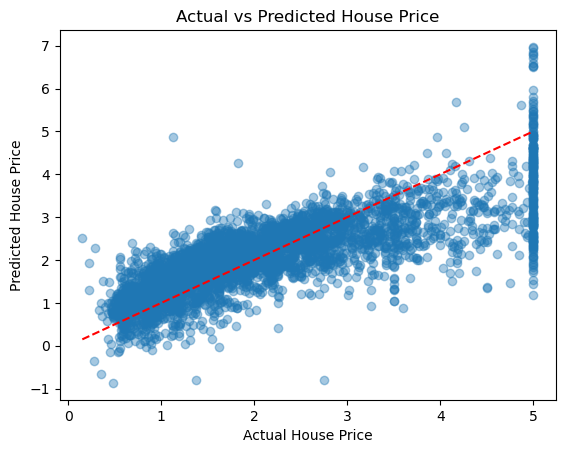

In [47]:
final_model=LinearRegression()
final_model.fit(x_train,y_train)

y_pred=final_model.predict(x_test)

plt.Figure(figsize=(10,6))
plt.scatter(y_test,y_pred,alpha=0.4)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],color='#ff0000',linestyle='--')
plt.show()